# 05 · Model Comparison

Compare the baseline and gradient-boosting model using validation choices and an untouched final month.

## Reading guide

This notebook is part of a connected workflow. It states the decision being made, shows the supporting checks and records limitations alongside the result. Source files are never modified in place.

In [1]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_ROOT = Path(os.environ.get("FIFAR_DATA_DIR", PROJECT_ROOT / "data" / "raw" / "FiFAR"))
REPORTS = PROJECT_ROOT / "reports"
IMAGES = PROJECT_ROOT / "images"

sns.set_theme(style="whitegrid")
CORAL = "#F08FA0"
TEAL = "#0E6268"
DARK = "#15262B"

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        "Set FIFAR_DATA_DIR to the extracted official FiFAR directory before running this notebook."
    )

In [2]:
metrics = json.loads((REPORTS / 'model_metrics.json').read_text())

In [3]:
rows = []
for model_name, model_result in metrics["models"].items():
    for split in ["validation", "test"]:
        rows.append({"model": model_name, "split": split, **model_result[split]})
comparison = pd.DataFrame(rows)
comparison

,model,split,average_precision,roc_auc,precision,recall,balanced_accuracy,alert_rate
0,logistic_regression,validation,0.116364,0.841624,0.106518,0.391821,0.674981,0.046261
1,logistic_regression,test,0.132864,0.849821,0.157598,0.294118,0.635294,0.027519
2,hist_gradient_boosting,validation,0.147369,0.864474,0.127113,0.420482,0.691853,0.041602
3,hist_gradient_boosting,test,0.178916,0.873893,0.174357,0.394258,0.683158,0.033343


## 1. Ranking performance

In [4]:
comparison.pivot(index='model', columns='split', values=['average_precision', 'roc_auc'])

average_precision              roc_auc           
split                               test validation      test validation
model                                                                   
hist_gradient_boosting          0.178916   0.147369  0.873893   0.864474
logistic_regression             0.132864   0.116364  0.849821   0.841624

Average precision is the primary ranking metric because it reflects performance on the rare positive class. ROC AUC is reported as a secondary measure.

## 2. Review-capacity comparison

In [5]:
capacity = []
for model_name, result in metrics["models"].items():
    for row in result["test_capacity"]:
        capacity.append({"model": model_name, **row})
capacity = pd.DataFrame(capacity)
capacity

,model,review_share,review_capacity,fraud_captured,precision_at_capacity,recall_at_capacity
0,logistic_regression,0.01,968,234,0.241736,0.163866
1,logistic_regression,0.03,2905,438,0.150775,0.306723
2,logistic_regression,0.05,4842,561,0.115861,0.392857
3,logistic_regression,0.10,9684,815,0.084159,0.570728
4,hist_gradient_boosting,0.01,968,285,0.294421,0.199580
5,hist_gradient_boosting,0.03,2905,533,0.183477,0.373249
6,hist_gradient_boosting,0.05,4842,680,0.140438,0.476190
7,hist_gradient_boosting,0.10,9684,891,0.092007,0.623950


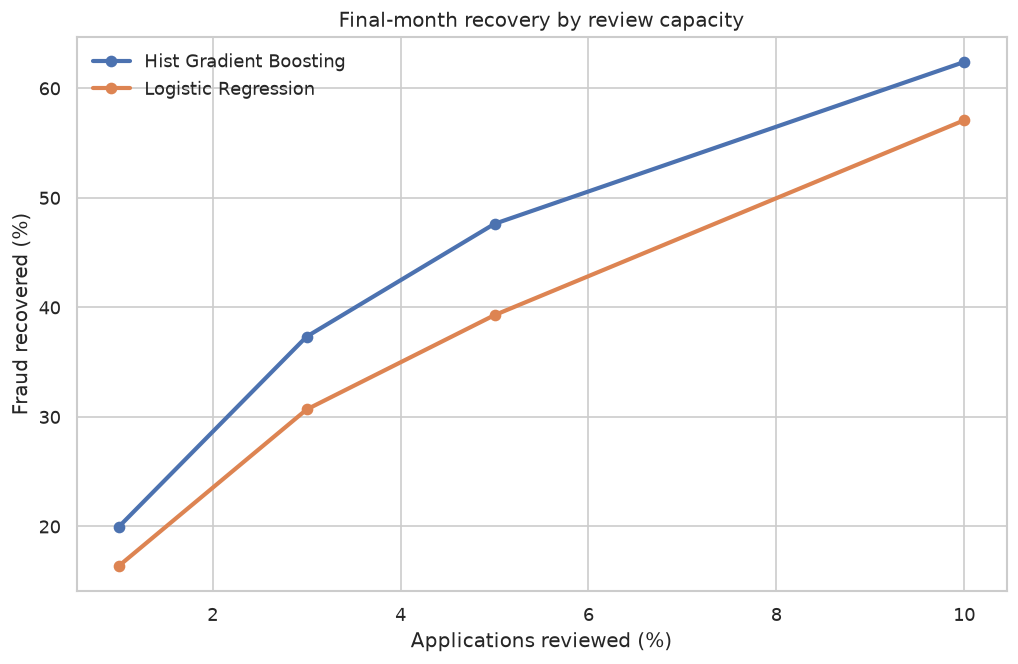

In [6]:
plt.figure(figsize=(10, 6))
for model_name, group in capacity.groupby("model"):
    plt.plot(group.review_share * 100, group.recall_at_capacity * 100, marker="o", linewidth=2.5, label=model_name.replace("_", " ").title())
plt.xlabel("Applications reviewed (%)")
plt.ylabel("Fraud recovered (%)")
plt.title("Final-month recovery by review capacity")
plt.legend(frameon=False)
plt.show()

## 3. Selection decision

In [7]:
three_percent = capacity[capacity.review_share.eq(.03)].set_index("model")
three_percent[["fraud_captured", "precision_at_capacity", "recall_at_capacity"]]

,fraud_captured,precision_at_capacity,recall_at_capacity
model,,,
logistic_regression,438,0.150775,0.306723
hist_gradient_boosting,533,0.183477,0.373249


Histogram gradient boosting is selected because it improves validation average precision and fraud recovery at every tested capacity. Its final-month results are reported once, after that selection.

## Limitation

The comparison covers two well-defined baselines, not an exhaustive model search. Additional models should be added only if they improve the validation result and preserve reproducibility.